# Custom CNN from Scratch for Date Fruit Classification

## Imports

In [1]:
from pathlib import Path
import time
import csv

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from torchvision import datasets, transforms
from PIL import Image

import matplotlib.pyplot as plt

## Project Paths and Device

In [2]:
ROOT = Path.cwd()

DATASET_DIR = ROOT / "datasets"
TRAIN_DIR = DATASET_DIR / "train"
VAL_DIR = DATASET_DIR / "val"
TEST_DIR = DATASET_DIR / "test"

CHECKPOINT_DIR = ROOT / "checkpoints"
CHECKPOINT_DIR.mkdir(exist_ok=True)

REPORTS_DIR = ROOT / "reports"
REPORTS_DIR.mkdir(exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Project root:", ROOT)
print("Train path:", TRAIN_DIR)
print("Validation path:", VAL_DIR)
print("Test path:", TEST_DIR)
print("Using device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Project root: c:\Users\PC\Desktop\ai-ml\cv-project
Train path: c:\Users\PC\Desktop\ai-ml\cv-project\datasets\train
Validation path: c:\Users\PC\Desktop\ai-ml\cv-project\datasets\val
Test path: c:\Users\PC\Desktop\ai-ml\cv-project\datasets\test
Using device: cuda
GPU: NVIDIA GeForce RTX 3050


## Configuration

In [3]:
IMAGE_SIZE = 128
BATCH_SIZE = 32
NUM_WORKERS = 0
PIN_MEMORY = torch.cuda.is_available()

EPOCHS = 15
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

BEST_MODEL_PATH = CHECKPOINT_DIR / "best_custom_cnn.pt"

print("Image size:", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)
print("Learning rate:", LEARNING_RATE)

Image size: 128
Batch size: 32
Epochs: 15
Learning rate: 0.001


## Transforms

In [4]:
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10, fill=255),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

eval_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

print("Training transforms:")
print(train_transforms)

print("\nEvaluation transforms:")
print(eval_transforms)

Training transforms:
Compose(
    Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=255)
    ToTensor()
    Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
)

Evaluation transforms:
Compose(
    Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
)


## Load Datasets

In [5]:
train_dataset = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=train_transforms
)

val_dataset = datasets.ImageFolder(
    root=VAL_DIR,
    transform=eval_transforms
)

test_dataset = datasets.ImageFolder(
    root=TEST_DIR,
    transform=eval_transforms
)

classes = train_dataset.classes
num_classes = len(classes)

print("Classes:")
for idx, class_name in enumerate(classes):
    print(f"{idx}: {class_name}")

print("\nTrain images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))

assert train_dataset.classes == val_dataset.classes == test_dataset.classes

Classes:
0: Ajwa
1: Aseel
2: Fasli-Toto
3: Galaxy
4: Medjool
5: Meneifi
6: Nabtat-Ali
7: Shaishe
8: Sokari
9: Sugaey

Train images: 4890
Validation images: 1050
Test images: 1060


## DataLoaders

In [6]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 153
Validation batches: 33
Test batches: 34


## Visualize One Batch

Batch image shape: torch.Size([32, 3, 128, 128])
Batch label shape: torch.Size([32])


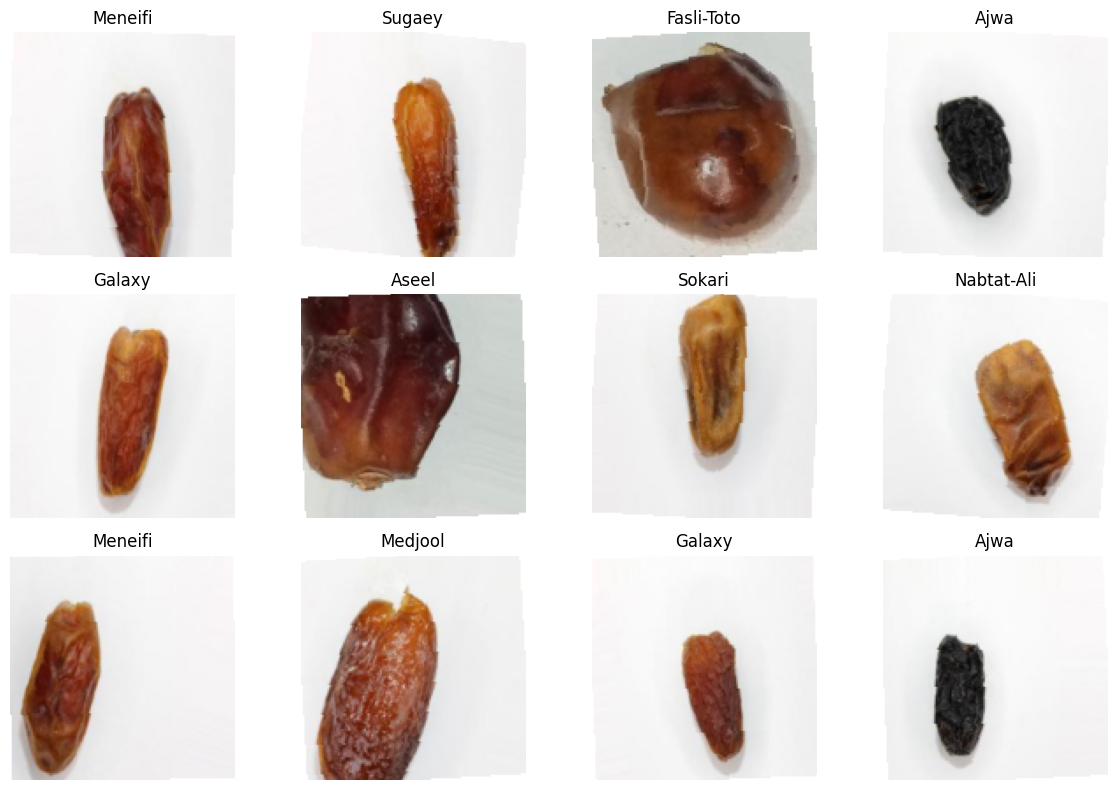

In [7]:
def denormalize_image(image_tensor):
    image = image_tensor.cpu() * 0.5 + 0.5
    image = image.clamp(0, 1)
    image = image.permute(1, 2, 0)
    return image


images, labels = next(iter(train_loader))

print("Batch image shape:", images.shape)
print("Batch label shape:", labels.shape)

plt.figure(figsize=(12, 8))

for i in range(min(12, len(images))):
    image = denormalize_image(images[i])
    label_name = classes[labels[i].item()]

    plt.subplot(3, 4, i + 1)
    plt.imshow(image)
    plt.title(label_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Custom CNN Model
This model uses:
- 3×3 convolution filters
- BatchNorm
- ReLU
- MaxPooling
- Dropout
- Final Linear layer

In [8]:
class CustomDateCNN(nn.Module):
    """
    Simple CNN trained from scratch.

    This model does not use pretrained weights.
    """

    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(p=0.30),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = CustomDateCNN(num_classes=num_classes)
model = model.to(DEVICE)

print(model)

CustomDateCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=T

## Parameter Count

In [9]:
def count_parameters(model):
    total_params = sum(param.numel() for param in model.parameters())
    trainable_params = sum(param.numel() for param in model.parameters() if param.requires_grad)

    return total_params, trainable_params


total_params, trainable_params = count_parameters(model)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters:     391,946
Trainable parameters: 391,946


## Forward Pass Check

In [10]:
images, labels = next(iter(train_loader))

images = images.to(DEVICE)
labels = labels.to(DEVICE)

model.eval()

with torch.no_grad():
    outputs = model(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)
print("Labels shape:", labels.shape)

Input shape: torch.Size([32, 3, 128, 128])
Output shape: torch.Size([32, 10])
Labels shape: torch.Size([32])


## Loss, Optimizer, Scheduler

In [11]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.3,
    patience=2
)

print("Loss:", criterion)
print("Optimizer:", optimizer)
print("Scheduler:", scheduler)

Loss: CrossEntropyLoss()
Optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)
Scheduler: <torch.optim.lr_scheduler.ReduceLROnPlateau object at 0x000002930FB22120>


## Training Function

In [12]:
def train_one_epoch(model, data_loader, optimizer, criterion, device):
    model.train()

    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for images, labels in data_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)

        running_loss += loss.item() * batch_size

        predicted_classes = outputs.argmax(dim=1)
        correct_predictions += (predicted_classes == labels).sum().item()

        total_samples += batch_size

    average_loss = running_loss / total_samples
    accuracy = correct_predictions / total_samples

    return average_loss, accuracy

## Evaluation Function

In [13]:
@torch.no_grad()
def evaluate(model, data_loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for images, labels in data_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        loss = criterion(outputs, labels)

        batch_size = labels.size(0)

        running_loss += loss.item() * batch_size

        predicted_classes = outputs.argmax(dim=1)
        correct_predictions += (predicted_classes == labels).sum().item()

        total_samples += batch_size

    average_loss = running_loss / total_samples
    accuracy = correct_predictions / total_samples

    return average_loss, accuracy

## Train Custom CNN

In [14]:
best_val_accuracy = 0.0

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

print("Starting custom CNN training...\n")

for epoch in range(1, EPOCHS + 1):
    start_time = time.time()

    train_loss, train_acc = train_one_epoch(
        model=model,
        data_loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=DEVICE
    )

    val_loss, val_acc = evaluate(
        model=model,
        data_loader=val_loader,
        criterion=criterion,
        device=DEVICE
    )

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    epoch_time = time.time() - start_time

    print(
        f"Epoch [{epoch}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Time: {epoch_time:.1f}s"
    )

    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "classes": classes,
            "class_to_idx": train_dataset.class_to_idx,
            "val_accuracy": val_acc,
            "image_size": IMAGE_SIZE,
            "model_name": "CustomDateCNN",
            "training_type": "from_scratch"
        }, BEST_MODEL_PATH)

        print(f"Saved best custom model: {BEST_MODEL_PATH}")

print("\nTraining completed.")
print(f"Best validation accuracy: {best_val_accuracy:.4f}")

Starting custom CNN training...

Epoch [1/15] | Train Loss: 0.8869 | Train Acc: 0.7168 | Val Loss: 0.6795 | Val Acc: 0.7533 | Time: 13.6s
Saved best custom model: c:\Users\PC\Desktop\ai-ml\cv-project\checkpoints\best_custom_cnn.pt
Epoch [2/15] | Train Loss: 0.4968 | Train Acc: 0.8415 | Val Loss: 4.8123 | Val Acc: 0.4410 | Time: 11.7s
Epoch [3/15] | Train Loss: 0.4114 | Train Acc: 0.8618 | Val Loss: 5.3693 | Val Acc: 0.3429 | Time: 11.7s
Epoch [4/15] | Train Loss: 0.3757 | Train Acc: 0.8708 | Val Loss: 4.3852 | Val Acc: 0.4638 | Time: 12.3s
Epoch [5/15] | Train Loss: 0.2714 | Train Acc: 0.9088 | Val Loss: 1.7589 | Val Acc: 0.6943 | Time: 12.1s
Epoch [6/15] | Train Loss: 0.2440 | Train Acc: 0.9198 | Val Loss: 0.4786 | Val Acc: 0.8200 | Time: 11.8s
Saved best custom model: c:\Users\PC\Desktop\ai-ml\cv-project\checkpoints\best_custom_cnn.pt
Epoch [7/15] | Train Loss: 0.2305 | Train Acc: 0.9229 | Val Loss: 0.2282 | Val Acc: 0.9238 | Time: 11.9s
Saved best custom model: c:\Users\PC\Desktop\a

## Plot Training Curves

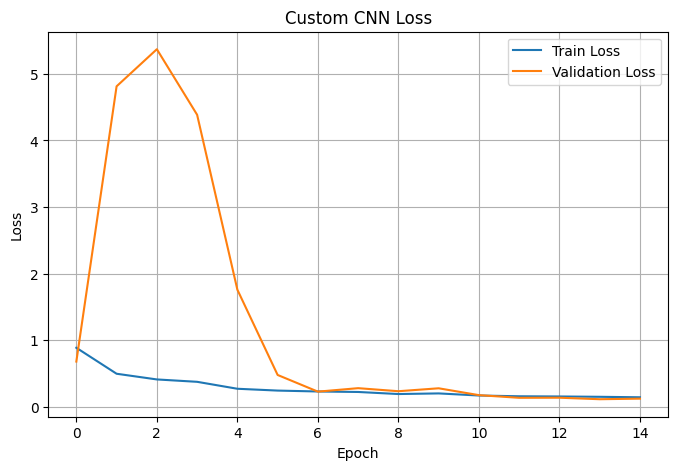

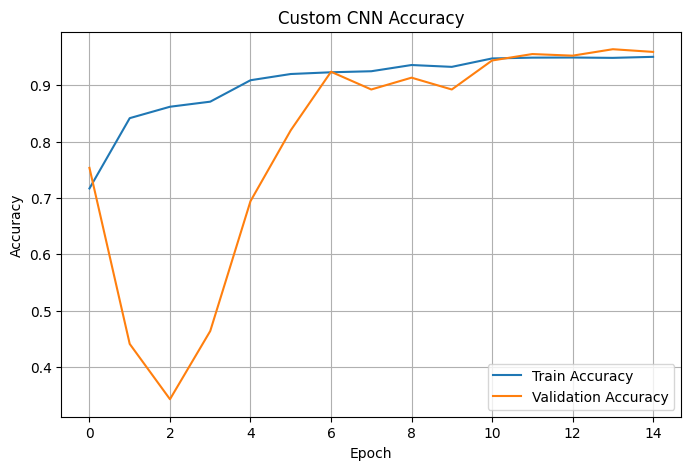

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Custom CNN Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Custom CNN Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## Load Best Custom Model

In [16]:
checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE
)

model = CustomDateCNN(num_classes=len(checkpoint["classes"]))
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(DEVICE)
model.eval()

classes = checkpoint["classes"]

print("Loaded best custom CNN model.")
print("Best validation accuracy:", checkpoint["val_accuracy"])
print("Best epoch:", checkpoint["epoch"])

Loaded best custom CNN model.
Best validation accuracy: 0.9638095238095238
Best epoch: 14


# Final Test Evaluation

In [17]:
test_loss, test_accuracy = evaluate(
    model=model,
    data_loader=test_loader,
    criterion=criterion,
    device=DEVICE
)

print(f"Custom CNN Test Loss: {test_loss:.4f}")
print(f"Custom CNN Test Accuracy: {test_accuracy:.4f}")
print(f"Custom CNN Test Accuracy (%): {test_accuracy * 100:.2f}%")

Custom CNN Test Loss: 0.1182
Custom CNN Test Accuracy: 0.9679
Custom CNN Test Accuracy (%): 96.79%


## Collect Predictions

In [18]:
@torch.no_grad()
def collect_predictions(model, data_loader, device):
    model.eval()

    all_true_labels = []
    all_pred_labels = []
    all_confidences = []

    for images, labels in data_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)

        probabilities = torch.softmax(outputs, dim=1)
        confidences, predicted_labels = torch.max(probabilities, dim=1)

        all_true_labels.append(labels.cpu())
        all_pred_labels.append(predicted_labels.cpu())
        all_confidences.append(confidences.cpu())

    all_true_labels = torch.cat(all_true_labels)
    all_pred_labels = torch.cat(all_pred_labels)
    all_confidences = torch.cat(all_confidences)

    return all_true_labels, all_pred_labels, all_confidences


true_labels, pred_labels, confidences = collect_predictions(
    model=model,
    data_loader=test_loader,
    device=DEVICE
)

print("Test samples:", len(true_labels))
print("Predictions:", len(pred_labels))

Test samples: 1060
Predictions: 1060


## Confusion Matrix

In [19]:
def build_confusion_matrix(true_labels, pred_labels, num_classes):
    cm = torch.zeros(num_classes, num_classes, dtype=torch.int64)

    for true_label, pred_label in zip(true_labels, pred_labels):
        cm[true_label, pred_label] += 1

    return cm


confusion_matrix = build_confusion_matrix(
    true_labels=true_labels,
    pred_labels=pred_labels,
    num_classes=num_classes
)

print("Confusion Matrix:")
print(confusion_matrix)

Confusion Matrix:
tensor([[106,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0, 104,   2,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0, 106,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,  99,   0,   4,   0,   1,   1,   1],
        [  0,   0,   0,   1, 101,   0,   3,   0,   0,   1],
        [  0,   0,   0,   2,   1,  97,   0,   0,   0,   6],
        [  0,   0,   0,   0,   0,   0, 105,   0,   0,   1],
        [  0,   0,   0,   0,   2,   0,   0, 104,   0,   0],
        [  0,   0,   0,   2,   0,   0,   0,   0, 104,   0],
        [  0,   0,   0,   0,   2,   2,   1,   0,   1, 100]])


## Plot Confusion Matrix

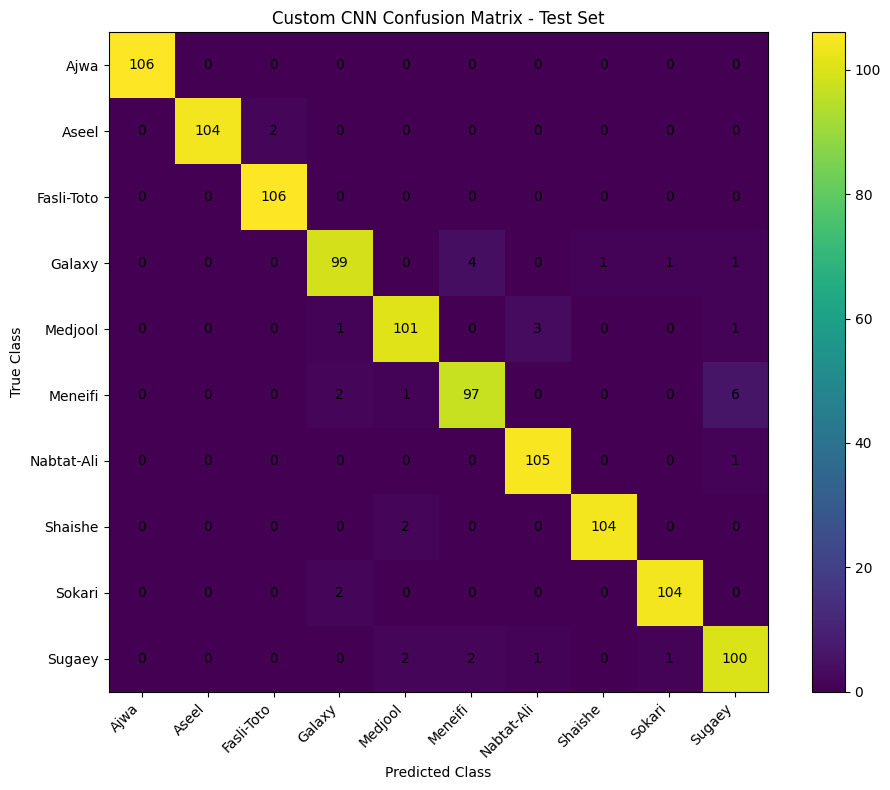

Saved confusion matrix: c:\Users\PC\Desktop\ai-ml\cv-project\reports\custom_cnn_confusion_matrix_test.png


In [20]:
plt.figure(figsize=(10, 8))

plt.imshow(confusion_matrix, interpolation="nearest")
plt.title("Custom CNN Confusion Matrix - Test Set")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.colorbar()

tick_marks = range(num_classes)

plt.xticks(
    tick_marks,
    classes,
    rotation=45,
    ha="right"
)

plt.yticks(
    tick_marks,
    classes
)

for i in range(num_classes):
    for j in range(num_classes):
        value = confusion_matrix[i, j].item()

        plt.text(
            j,
            i,
            str(value),
            ha="center",
            va="center"
        )

plt.tight_layout()

custom_cm_path = REPORTS_DIR / "custom_cnn_confusion_matrix_test.png"
plt.savefig(custom_cm_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved confusion matrix:", custom_cm_path)

## Simple Class Metrics

In [21]:
def calculate_metrics(confusion_matrix, class_names):
    metrics = []

    total_correct = confusion_matrix.diag().sum().item()
    total_samples = confusion_matrix.sum().item()
    overall_accuracy = total_correct / total_samples

    for class_index, class_name in enumerate(class_names):
        tp = confusion_matrix[class_index, class_index].item()

        fp = confusion_matrix[:, class_index].sum().item() - tp
        fn = confusion_matrix[class_index, :].sum().item() - tp

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0

        f1 = (
            2 * precision * recall / (precision + recall)
            if (precision + recall) > 0
            else 0.0
        )

        support = confusion_matrix[class_index, :].sum().item()

        metrics.append({
            "class_name": class_name,
            "precision": precision,
            "recall": recall,
            "f1_score": f1,
            "support": support
        })

    return metrics, overall_accuracy


class_metrics, overall_accuracy = calculate_metrics(
    confusion_matrix=confusion_matrix,
    class_names=classes
)

print(f"Overall Accuracy: {overall_accuracy:.4f}")
print()

print(f"{'Class':15s} | {'Precision':>9s} | {'Recall':>9s} | {'F1-score':>9s} | {'Support':>7s}")
print("-" * 70)

for item in class_metrics:
    print(
        f"{item['class_name']:15s} | "
        f"{item['precision']:9.4f} | "
        f"{item['recall']:9.4f} | "
        f"{item['f1_score']:9.4f} | "
        f"{item['support']:7d}"
    )

Overall Accuracy: 0.9679

Class           | Precision |    Recall |  F1-score | Support
----------------------------------------------------------------------
Ajwa            |    1.0000 |    1.0000 |    1.0000 |     106
Aseel           |    1.0000 |    0.9811 |    0.9905 |     106
Fasli-Toto      |    0.9815 |    1.0000 |    0.9907 |     106
Galaxy          |    0.9519 |    0.9340 |    0.9429 |     106
Medjool         |    0.9528 |    0.9528 |    0.9528 |     106
Meneifi         |    0.9417 |    0.9151 |    0.9282 |     106
Nabtat-Ali      |    0.9633 |    0.9906 |    0.9767 |     106
Shaishe         |    0.9905 |    0.9811 |    0.9858 |     106
Sokari          |    0.9811 |    0.9811 |    0.9811 |     106
Sugaey          |    0.9174 |    0.9434 |    0.9302 |     106


## Final Comparison Summary

In [22]:
print("Custom CNN Final Summary")
print("=" * 50)

print("Model type: Custom CNN")
print("Pretrained weights: No")
print("Training type: From scratch")
print(f"Image size: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"Best validation accuracy: {checkpoint['val_accuracy']:.4f}")
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test accuracy (%): {test_accuracy * 100:.2f}%")
print(f"Saved model: {BEST_MODEL_PATH}")

Custom CNN Final Summary
Model type: Custom CNN
Pretrained weights: No
Training type: From scratch
Image size: 128x128
Best validation accuracy: 0.9638
Test loss: 0.1182
Test accuracy: 0.9679
Test accuracy (%): 96.79%
Saved model: c:\Users\PC\Desktop\ai-ml\cv-project\checkpoints\best_custom_cnn.pt
